## Corruption visualization

This notebook visualize the corruption types and it's severity (0: clean to 4: very corrupted)

This is the different types of corruption

1. Gaussian Noise
Simulates sensor noise
• mean = 0
• variance = controllable

2. Motion / Gaussian Blur
Simulates camera motion or focus issues

3. Occlusion (Cutout)
Random black square blocks
• simulate object obstruction

4. JPEG Compression Artifacts
Simulates low-quality image transmission
• quality factor: 10 → 100

5. Brightness / Contrast shift (optional upgrade)
Simulates lighting conditions

6. Image augmentation
Make some random rotations on images

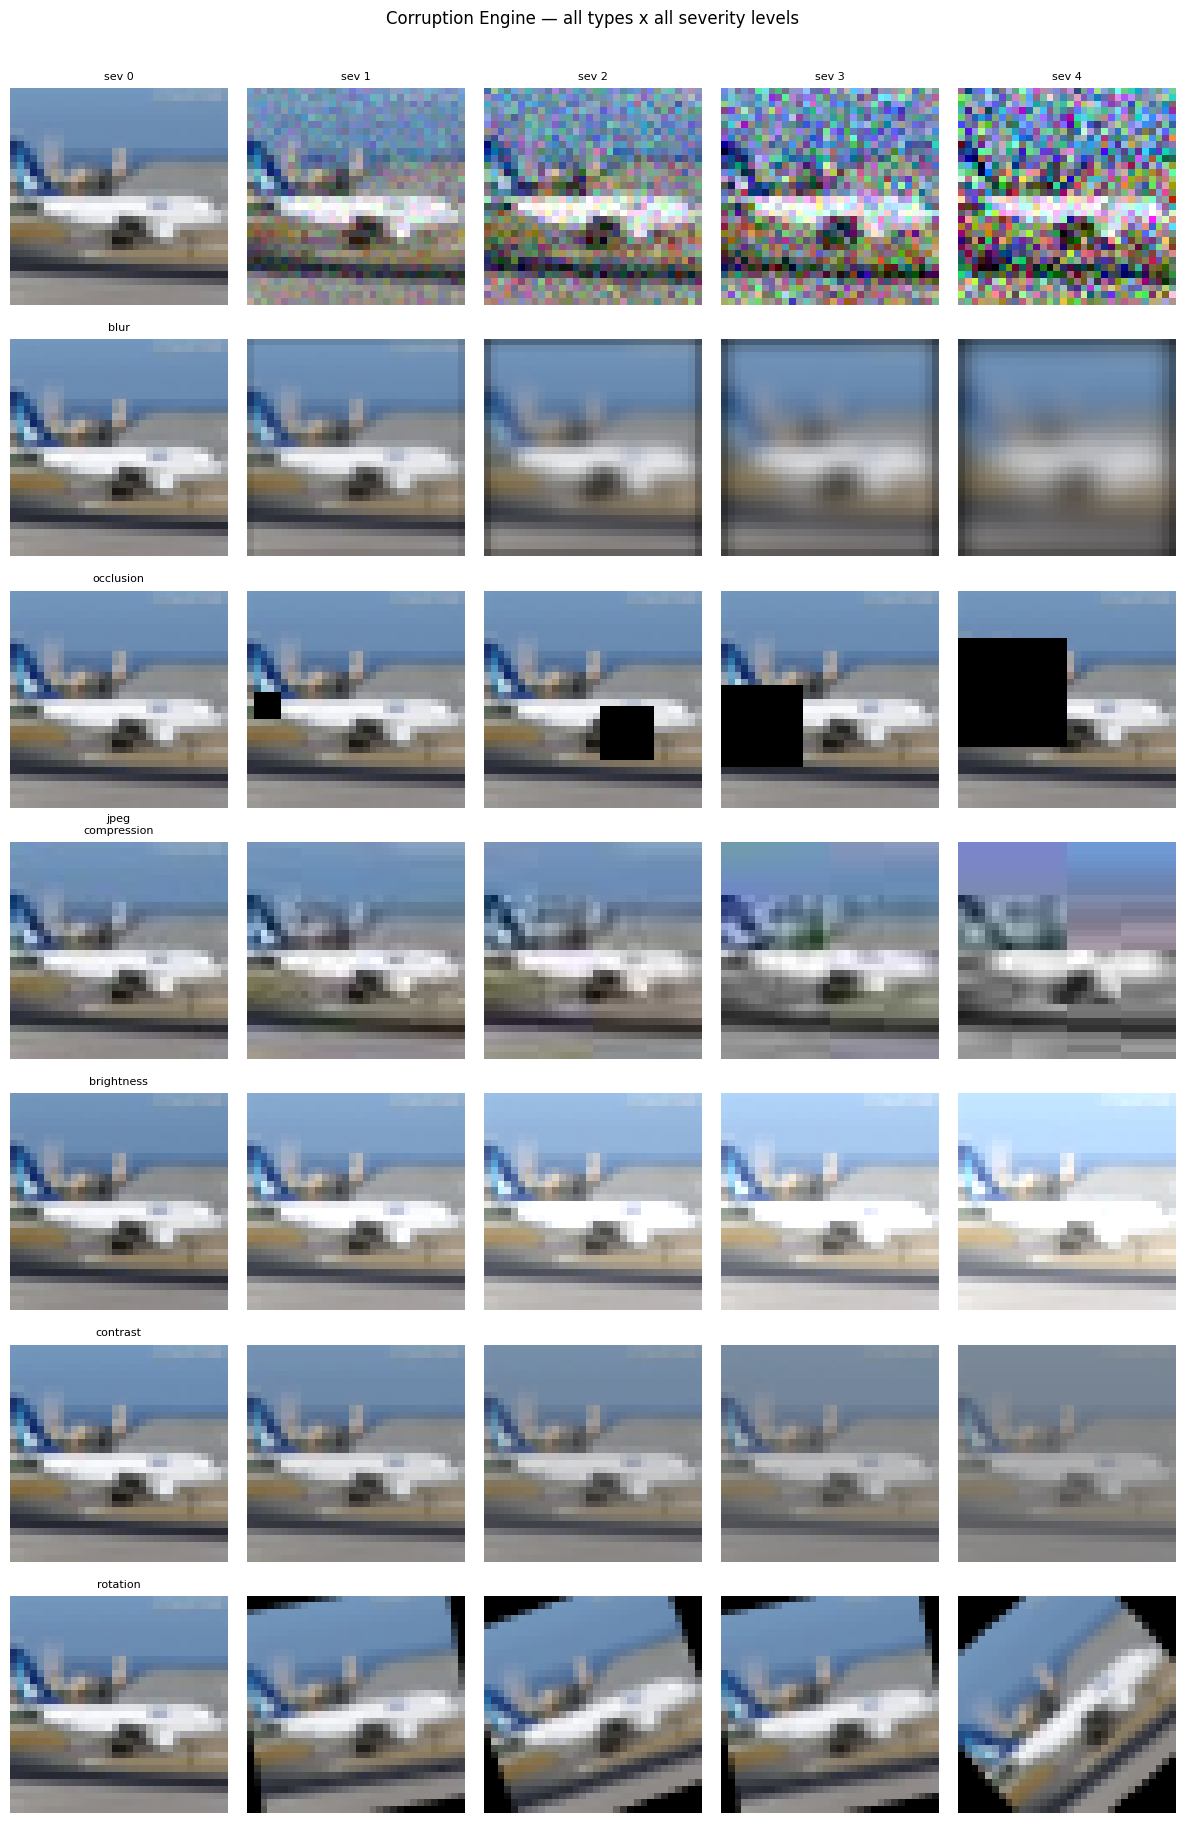

In [1]:
import torch, matplotlib.pyplot as plt
from torchvision import datasets, transforms

import sys, os
sys.path.insert(0, os.path.abspath(".."))

from src.datasets.corruption_engine import apply_corruption, CORRUPTION_TYPES

DATA_PATH = os.path.join('..', 'data', 'raw')

# Load one batch from CIFAR-10
dataset = datasets.CIFAR10(root=DATA_PATH, train=False, download=False,
                           transform=transforms.ToTensor())
img, label = dataset[90]   # shape: (3, 32, 32), float [0,1]

severities = [0, 1, 2, 3, 4]
corruptions = ["gaussian_noise", "blur", "occlusion",
               "jpeg_compression", "brightness", "contrast", "rotation"]

fig, axes = plt.subplots(len(corruptions), len(severities),
                         figsize=(12, 18))

for row, ctype in enumerate(corruptions):
    for col, sev in enumerate(severities):
        corrupted = apply_corruption(img, ctype, sev)
        axes[row, col].imshow(corrupted.permute(1, 2, 0).numpy())
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_title(ctype.replace("_", "\n"), fontsize=8)
        if row == 0:
            axes[row, col].set_title(f"sev {sev}", fontsize=8)

plt.suptitle("Corruption Engine — all types x all severity levels", y=1.01)
plt.tight_layout()
plt.savefig("../results/plots/corruption_grid.png", dpi=150, bbox_inches="tight")
plt.show()